In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
# Cargar archivos de entrenamiento y validación
df_train = pd.read_csv('hoteles-entrena.csv')
df_test = pd.read_csv('hoteles-prueba.csv')

# Mostrar las dimensiones de cada conjunto
print("Dimensiones de entrenamiento:", df_train.shape)
print("Dimensiones de validación:", df_test.shape)

Dimensiones de entrenamiento: (52981, 25)
Dimensiones de validación: (22185, 25)


In [3]:
df_train

,hotel,lead_time,stays_in_weekend_nights,stays_in_week_nights,adults,children,meal,country,market_segment,distribution_channel,...,booking_changes,deposit_type,agent,company,days_in_waiting_list,customer_type,average_daily_rate,required_car_parking_spaces,total_of_special_requests,arrival_date
0,Resort_Hotel,342,0,0,2,none,BB,PRT,Direct,Direct,...,3,No_Deposit,NaN,NaN,0,Transient,0.00,none,0,2015-07-01
1,Resort_Hotel,737,0,0,2,none,BB,PRT,Direct,Direct,...,4,No_Deposit,NaN,NaN,0,Transient,0.00,none,0,2015-07-01
2,Resort_Hotel,7,0,1,1,none,BB,GBR,Direct,Direct,...,0,No_Deposit,NaN,NaN,0,Transient,75.00,none,0,2015-07-01
3,Resort_Hotel,13,0,1,1,none,BB,GBR,Corporate,Corporate,...,0,No_Deposit,304.0,NaN,0,Transient,75.00,none,0,2015-07-01
4,Resort_Hotel,14,0,2,2,none,BB,GBR,Online_TA,TA/TO,...,0,No_Deposit,240.0,NaN,0,Transient,98.00,none,1,2015-07-01
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
52976,City_Hotel,23,2,5,2,none,BB,BEL,Offline_TA/TO,TA/TO,...,0,No_Deposit,394.0,NaN,0,Transient,96.14,none,0,2017-08-30
52977,City_Hotel,102,2,5,3,none,BB,FRA,Online_TA,TA/TO,...,0,No_Deposit,9.0,NaN,0,Transient,225.43,none,2,2017-08-31
52978,City_Hotel,34,2,5,2,none,BB,DEU,Online_TA,TA/TO,...,0,No_Deposit,9.0,NaN,0,Transient,157.71,none,4,2017-08-31
52979,City_Hotel,109,2,5,2,none,BB,GBR,Online_TA,TA/TO,...,0,No_Deposit,89.0,NaN,0,Transient,104.40,none,0,2017-08-31


In [4]:
# Descripción de las columnas numéricas
df_train.describe().T

,count,mean,std,min,25%,50%,75%,max
lead_time,52981.0,79.968913,90.959584,0.00,9.00,45.00,124.0,737.0
stays_in_weekend_nights,52981.0,0.928559,0.988730,0.00,0.00,1.00,2.0,18.0
stays_in_week_nights,52981.0,2.463544,1.907669,0.00,1.00,2.00,3.0,42.0
adults,52981.0,1.828901,0.511329,0.00,2.00,2.00,2.0,4.0
is_repeated_guest,52981.0,0.043223,0.203361,0.00,0.00,0.00,0.0,1.0
previous_cancellations,52981.0,0.016176,0.280051,0.00,0.00,0.00,0.0,13.0
previous_bookings_not_canceled,52981.0,0.201959,1.825034,0.00,0.00,0.00,0.0,72.0
booking_changes,52981.0,0.293822,0.732195,0.00,0.00,0.00,0.0,20.0
agent,44338.0,94.409310,114.380340,1.00,9.00,14.00,240.0,535.0
company,3939.0,191.722265,132.407868,6.00,51.00,192.00,270.0,541.0


In [5]:
# Información general de todas las columnas
df_train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 52981 entries, 0 to 52980
Data columns (total 25 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   hotel                           52981 non-null  object 
 1   lead_time                       52981 non-null  int64  
 2   stays_in_weekend_nights         52981 non-null  int64  
 3   stays_in_week_nights            52981 non-null  int64  
 4   adults                          52981 non-null  int64  
 5   children                        52981 non-null  object 
 6   meal                            52981 non-null  object 
 7   country                         52681 non-null  object 
 8   market_segment                  52981 non-null  object 
 9   distribution_channel            52981 non-null  object 
 10  is_repeated_guest               52981 non-null  int64  
 11  previous_cancellations          52981 non-null  int64  
 12  previous_bookings_not_canceled  

hotel                                2
lead_time                          418
stays_in_weekend_nights             15
stays_in_week_nights                27
adults                               5
children                             2
meal                                 5
country                            146
market_segment                       7
distribution_channel                 5
is_repeated_guest                    2
previous_cancellations               9
previous_bookings_not_canceled      61
reserved_room_type                   9
assigned_room_type                  10
booking_changes                     18
deposit_type                         3
agent                              298
company                            303
days_in_waiting_list                92
customer_type                        4
average_daily_rate                6393
required_car_parking_spaces          2
total_of_special_requests            6
arrival_date                       793
dtype: int64


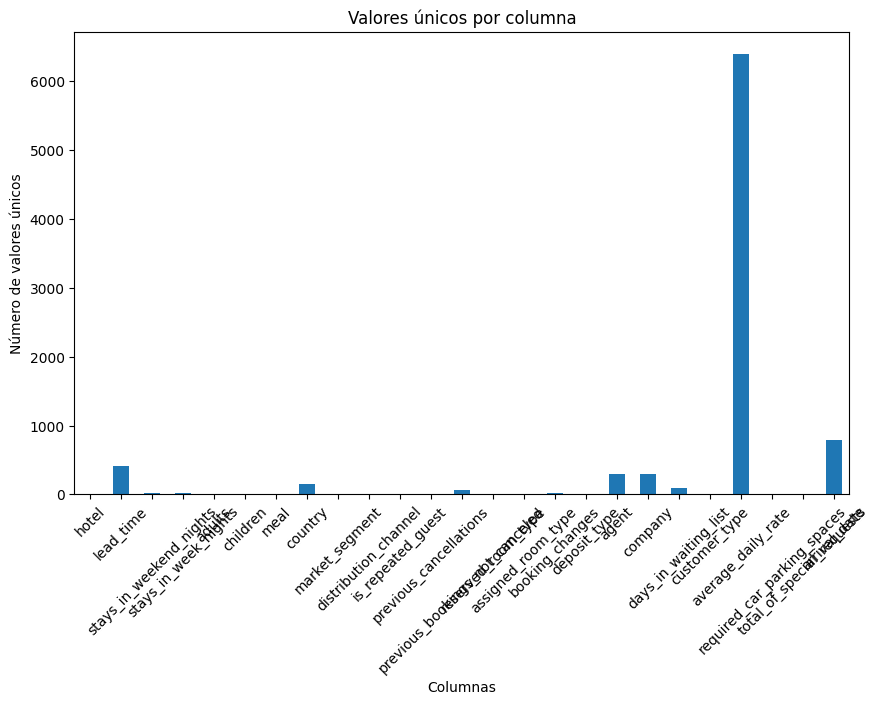

In [6]:
import matplotlib.pyplot as plt

# Contar los valores distintos por columna
valores_unicos = df_train.nunique()

# Mostrar los resultados
print(valores_unicos)

# Crear un histograma de los valores únicos por columna
plt.figure(figsize=(10, 6))
valores_unicos.plot(kind='bar')
plt.title('Valores únicos por columna')
plt.xlabel('Columnas')
plt.ylabel('Número de valores únicos')
plt.xticks(rotation=45)
plt.show()

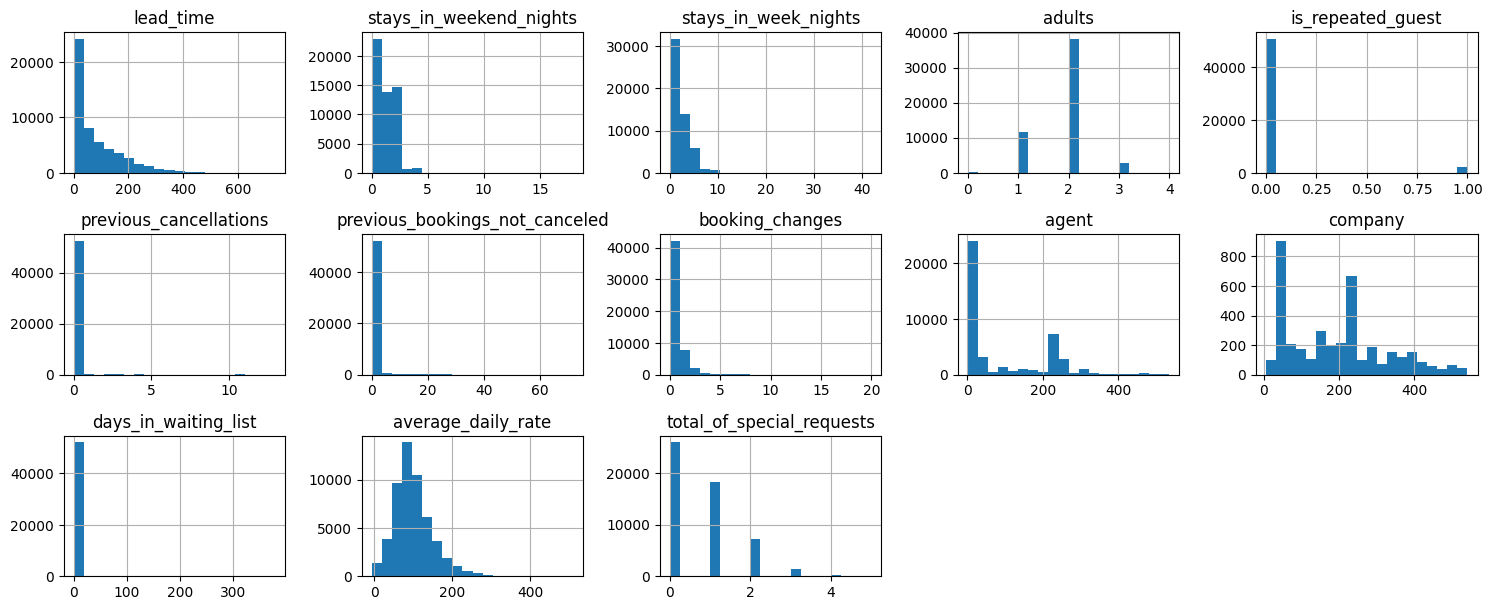

In [7]:
# Crear subplots para variables numéricas en un formato tipo "tableplot"
df_train.hist(bins=20, figsize=(15, 10), layout=(5, 5))  # Ajusta la layout si tienes más o menos columnas
plt.tight_layout()
plt.show()

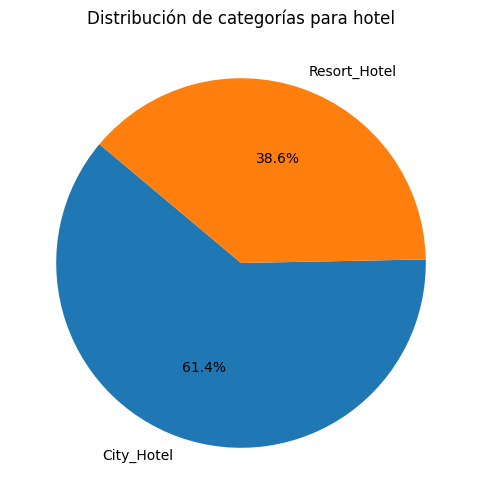

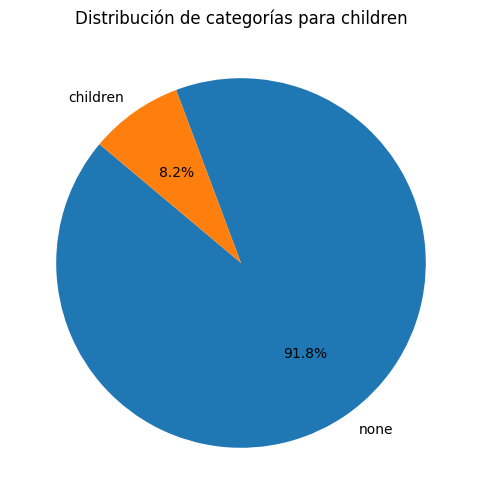

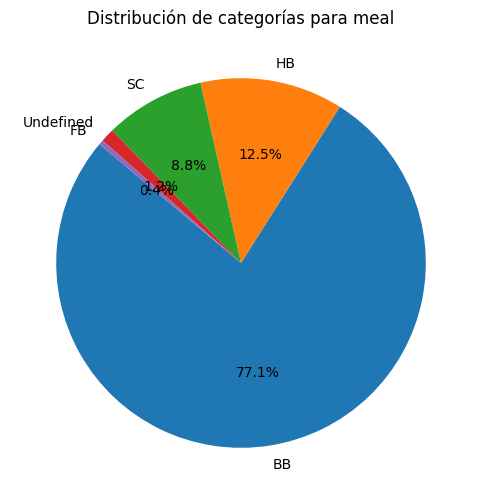

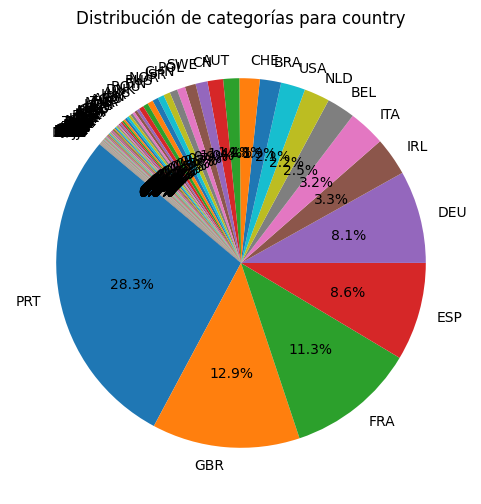

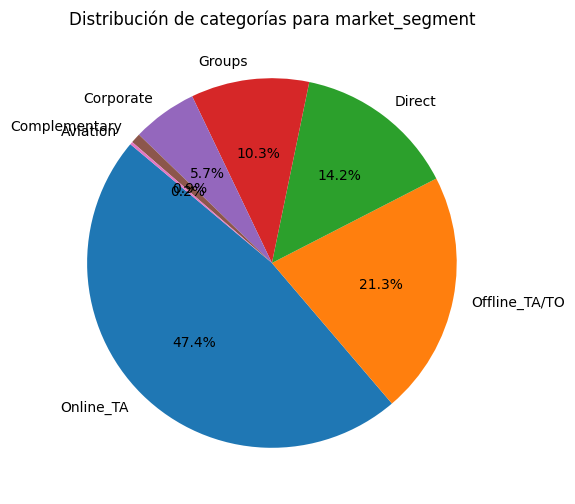

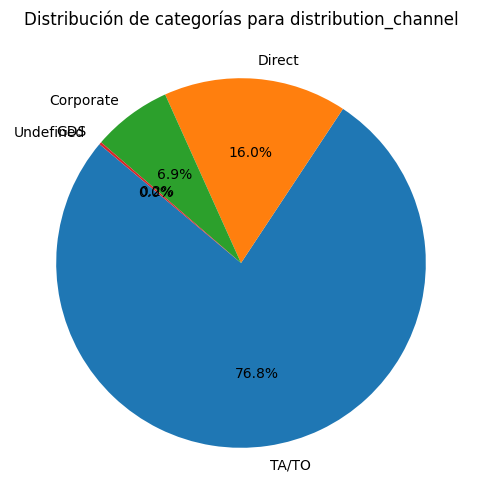

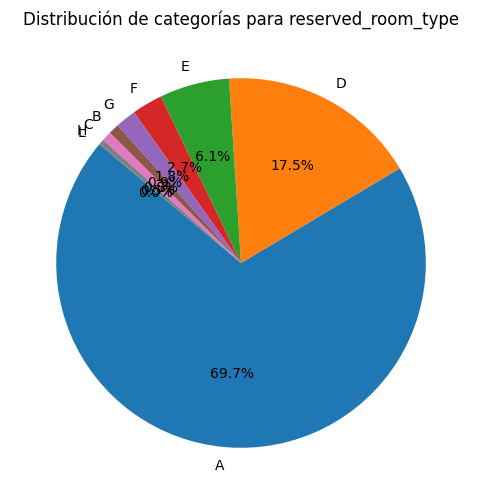

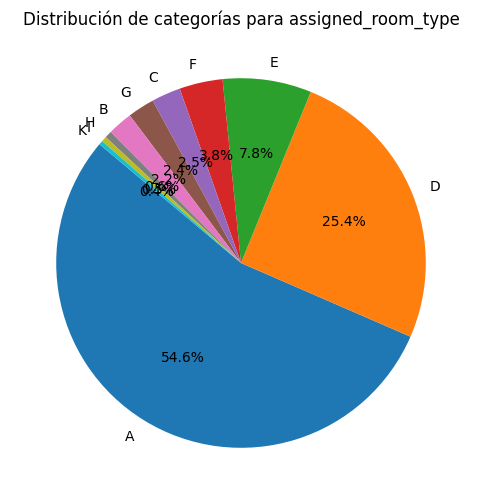

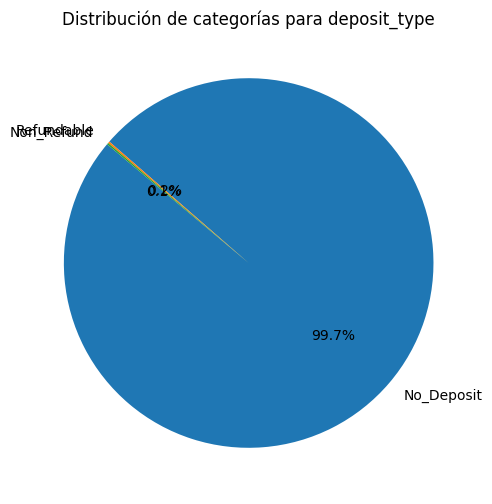

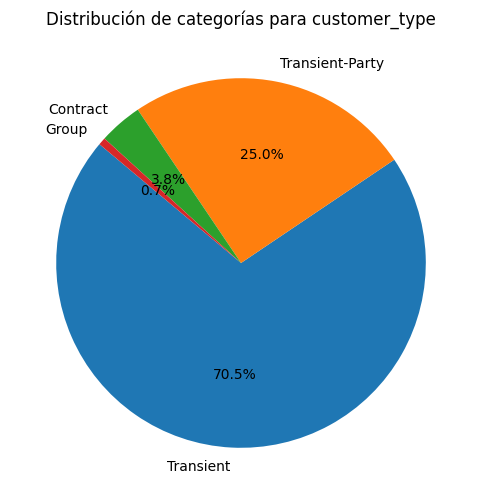

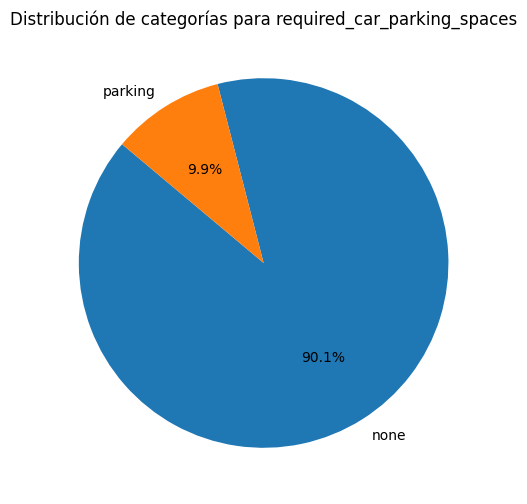

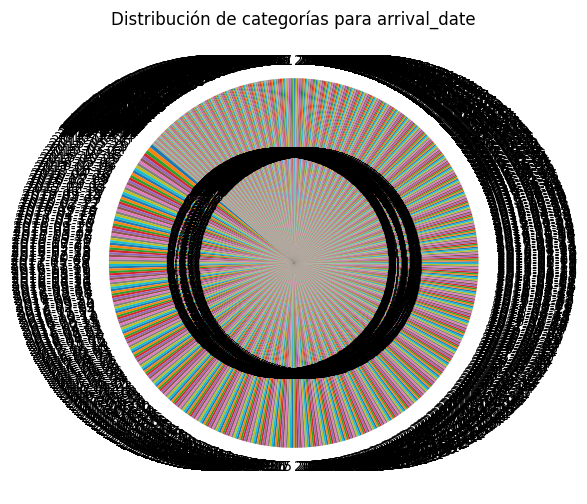

In [8]:
# Iterar sobre las columnas categóricas y crear gráficos de pastel
for column in df_train.select_dtypes(include=['object', 'category']).columns:
    plt.figure(figsize=(6, 6))
    df_train[column].value_counts(normalize=True).plot(kind='pie', autopct='%1.1f%%', startangle=140)
    plt.title(f'Distribución de categorías para {column}')
    plt.ylabel('')
    plt.show()

In [9]:
# Convertir la columna 'arrival_date' a formato datetime
df_train['arrival_date'] = pd.to_datetime(df_train['arrival_date'], format='%Y-%m-%d')

In [10]:
# Extraer año, mes y día
df_train['arrival_year'] = df_train['arrival_date'].dt.year
df_train['arrival_month'] = df_train['arrival_date'].dt.month
df_train['arrival_day'] = df_train['arrival_date'].dt.day

In [11]:
# Crear la columna day_of_year
df_train['day_of_year'] = df_train['arrival_date'].dt.dayofyear

In [12]:
# Añadir componentes seno y coseno para capturar estacionalidad
df_train['arrival_month_sin'] = np.sin(2 * np.pi * df_train['arrival_month'] / 12)
df_train['arrival_month_cos'] = np.cos(2 * np.pi * df_train['arrival_month'] / 12)

# Añadir componentes seno y coseno para capturar estacionalidad en day_of_year
df_train['day_of_year_sin'] = np.sin(2 * np.pi * df_train['day_of_year'] / 365)
df_train['day_of_year_cos'] = np.cos(2 * np.pi * df_train['day_of_year'] / 365)

# Visualizar las primeras filas
df_train[['arrival_date', 'arrival_year', 'arrival_month', 'arrival_day', 
          'arrival_month_sin', 'arrival_month_cos', 'day_of_year', 
          'day_of_year_sin', 'day_of_year_cos']].head()

,arrival_date,arrival_year,arrival_month,arrival_day,arrival_month_sin,arrival_month_cos,day_of_year,day_of_year_sin,day_of_year_cos
0,2015-07-01,2015,7,1,-0.5,-0.866025,182,0.008607,-0.999963
1,2015-07-01,2015,7,1,-0.5,-0.866025,182,0.008607,-0.999963
2,2015-07-01,2015,7,1,-0.5,-0.866025,182,0.008607,-0.999963
3,2015-07-01,2015,7,1,-0.5,-0.866025,182,0.008607,-0.999963
4,2015-07-01,2015,7,1,-0.5,-0.866025,182,0.008607,-0.999963


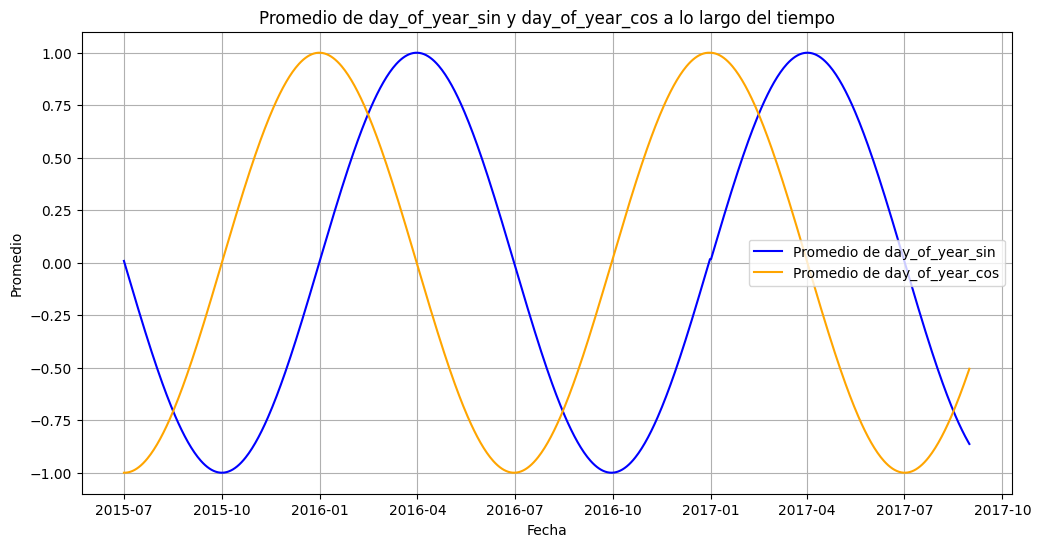

In [13]:
import matplotlib.pyplot as plt
import pandas as pd

# Asegurar que 'arrival_date' esté en formato datetime
df_train['arrival_date'] = pd.to_datetime(df_train['arrival_date'], format='%d/%m/%Y')

# Agrupar por fecha y calcular los promedios de day_of_year_sin y day_of_year_cos
promedios_por_fecha = df_train.groupby('arrival_date').agg({
    'day_of_year_sin': 'mean',
    'day_of_year_cos': 'mean'
}).reindex(pd.date_range(df_train['arrival_date'].min(), df_train['arrival_date'].max()), fill_value=0)

# Graficar la serie de tiempo
plt.figure(figsize=(12, 6))
plt.plot(promedios_por_fecha.index, promedios_por_fecha['day_of_year_sin'], label='Promedio de day_of_year_sin', color='blue')
plt.plot(promedios_por_fecha.index, promedios_por_fecha['day_of_year_cos'], label='Promedio de day_of_year_cos', color='orange')
plt.title('Promedio de day_of_year_sin y day_of_year_cos a lo largo del tiempo')
plt.xlabel('Fecha')
plt.ylabel('Promedio')
plt.legend()
plt.grid()
plt.show()

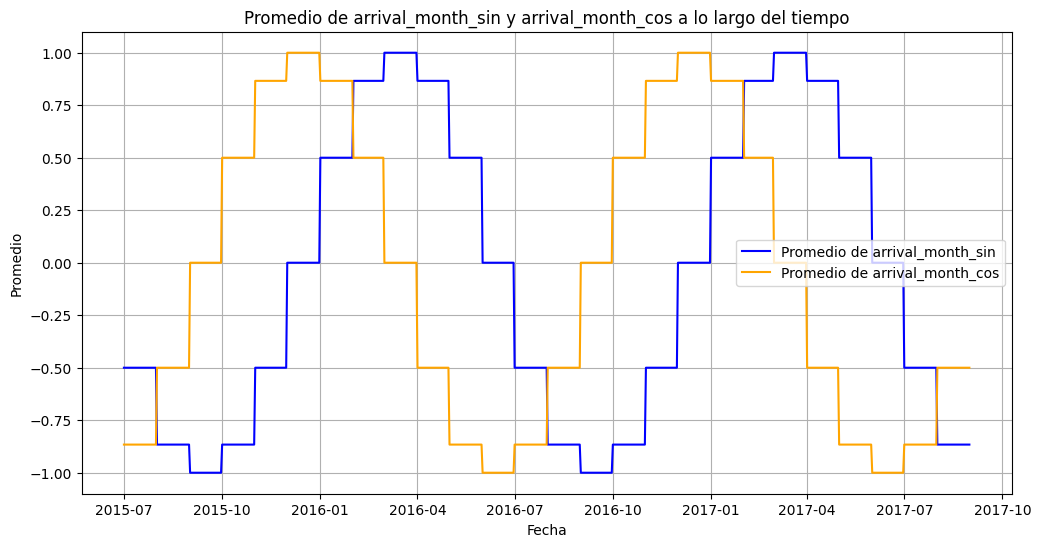

In [14]:
# Agrupar por fecha y calcular los promedios de arrival_month_sin y arrival_month_cos
promedios_por_fecha_mes = df_train.groupby('arrival_date').agg({
    'arrival_month_sin': 'mean',
    'arrival_month_cos': 'mean'
}).reindex(pd.date_range(df_train['arrival_date'].min(), df_train['arrival_date'].max()), fill_value=0)

# Graficar la serie de tiempo para los promedios de seno y coseno del mes
plt.figure(figsize=(12, 6))
plt.plot(promedios_por_fecha_mes.index, promedios_por_fecha_mes['arrival_month_sin'], label='Promedio de arrival_month_sin', color='blue')
plt.plot(promedios_por_fecha_mes.index, promedios_por_fecha_mes['arrival_month_cos'], label='Promedio de arrival_month_cos', color='orange')
plt.title('Promedio de arrival_month_sin y arrival_month_cos a lo largo del tiempo')
plt.xlabel('Fecha')
plt.ylabel('Promedio')
plt.legend()
plt.grid()
plt.show()

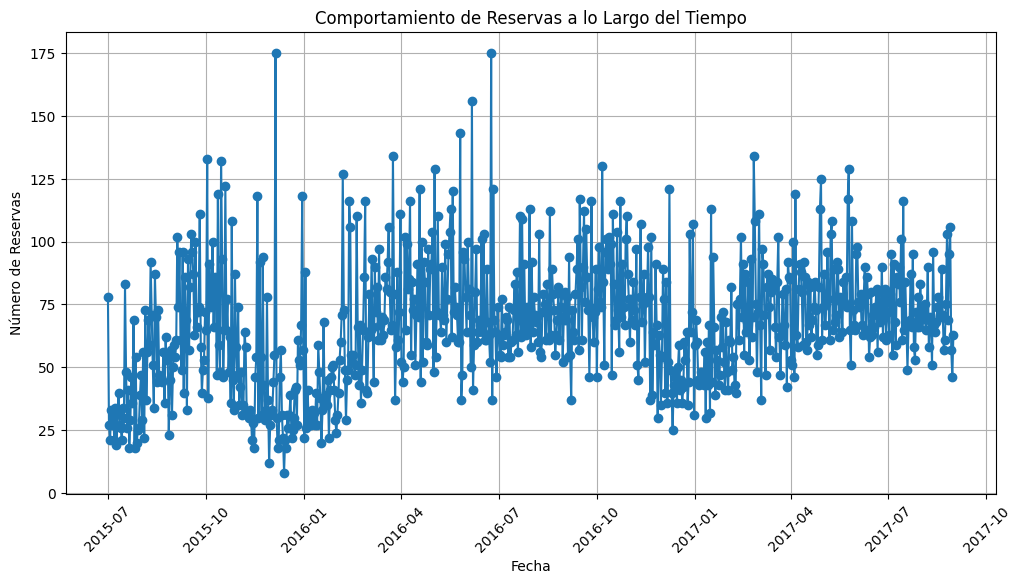

In [15]:
# Convertir 'arrival_date' a tipo datetime si no lo está ya
df_train['arrival_date'] = pd.to_datetime(df_train['arrival_date'], format='%Y-%m-%d')

# Agrupar las reservas por fecha
reservas_por_fecha = df_train['arrival_date'].value_counts().sort_index()

# Crear la gráfica de línea
plt.figure(figsize=(12, 6))
plt.plot(reservas_por_fecha.index, reservas_por_fecha.values, marker='o', linestyle='-')
plt.title('Comportamiento de Reservas a lo Largo del Tiempo')
plt.xlabel('Fecha')
plt.ylabel('Número de Reservas')
plt.xticks(rotation=45)
plt.grid()
plt.show()

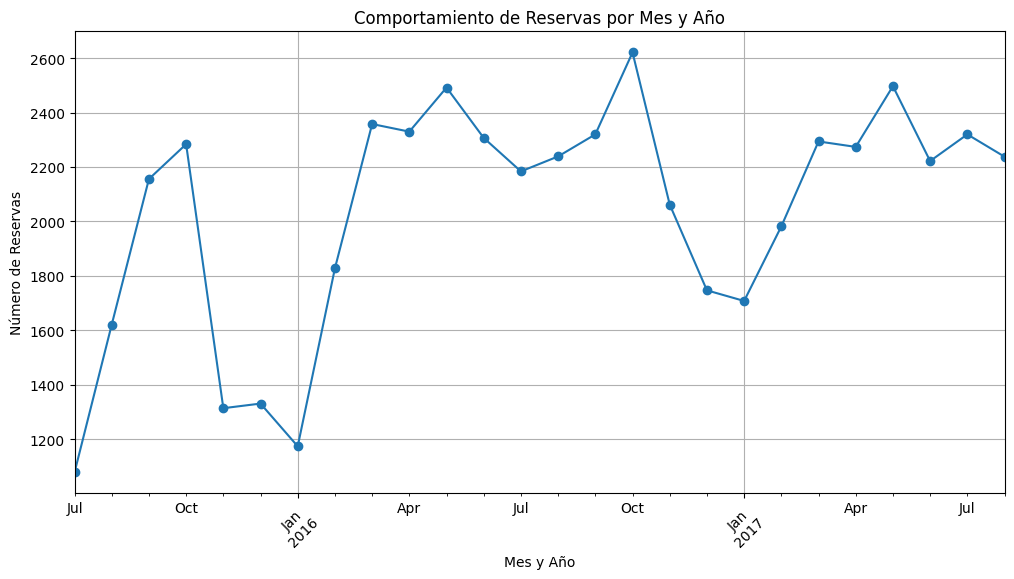

In [16]:
# Asegurarnos de que 'arrival_date' esté en formato datetime
df_train['arrival_date'] = pd.to_datetime(df_train['arrival_date'], format='%d/%m/%Y')

# Crear columnas de año y mes
df_train['arrival_year_month'] = df_train['arrival_date'].dt.to_period('M')

# Agrupar las reservas por año y mes
reservas_por_mes = df_train['arrival_year_month'].value_counts().sort_index()

# Graficar el comportamiento por mes y año
plt.figure(figsize=(12, 6))
reservas_por_mes.plot(kind='line', marker='o')
plt.title('Comportamiento de Reservas por Mes y Año')
plt.xlabel('Mes y Año')
plt.ylabel('Número de Reservas')
plt.xticks(rotation=45)
plt.grid()
plt.show()

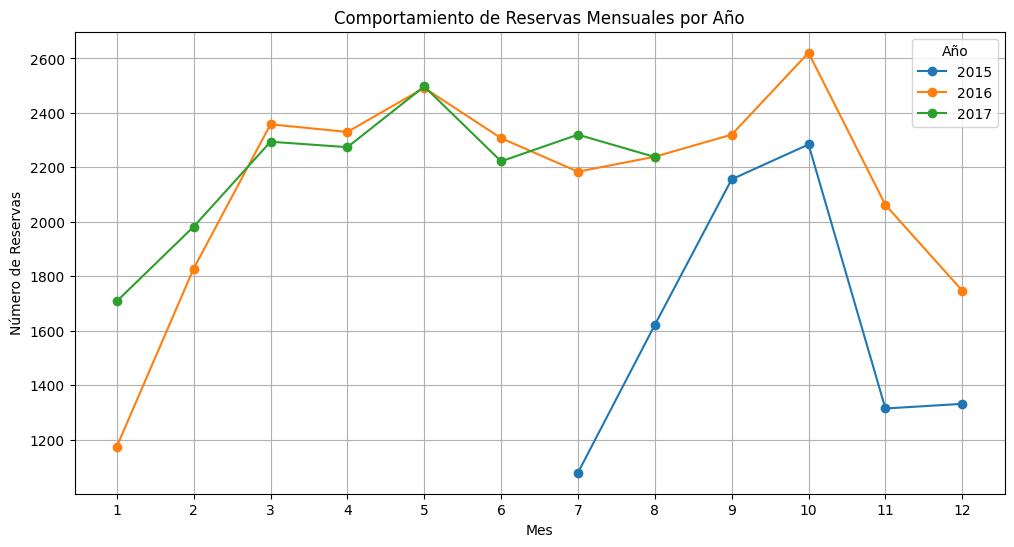

In [17]:
# Crear columnas de año y mes
df_train['arrival_year'] = df_train['arrival_date'].dt.year
df_train['arrival_month'] = df_train['arrival_date'].dt.month

# Agrupar por año y mes, y contar reservas
reservas_por_mes_año = df_train.groupby(['arrival_year', 'arrival_month']).size().unstack(level=0)

# Graficar líneas por año
plt.figure(figsize=(12, 6))
for year in reservas_por_mes_año.columns:
    plt.plot(reservas_por_mes_año.index, reservas_por_mes_año[year], marker='o', label=year)

plt.title('Comportamiento de Reservas Mensuales por Año')
plt.xlabel('Mes')
plt.ylabel('Número de Reservas')
plt.xticks(range(1, 13))  # Etiquetas de 1 a 12 para cada mes
plt.legend(title='Año')
plt.grid()
plt.show()

In [18]:
# Sumar stays_in_weekend_nights y stays_in_week_nights como total de noches
df_train['total_nights'] = df_train['stays_in_weekend_nights'] + df_train['stays_in_week_nights']

# Visualizar las primeras filas para verificar
df_train[['stays_in_weekend_nights', 'stays_in_week_nights', 'total_nights']].head()

,stays_in_weekend_nights,stays_in_week_nights,total_nights
0,0,0,0
1,0,0,0
2,0,1,1
3,0,1,1
4,0,2,2


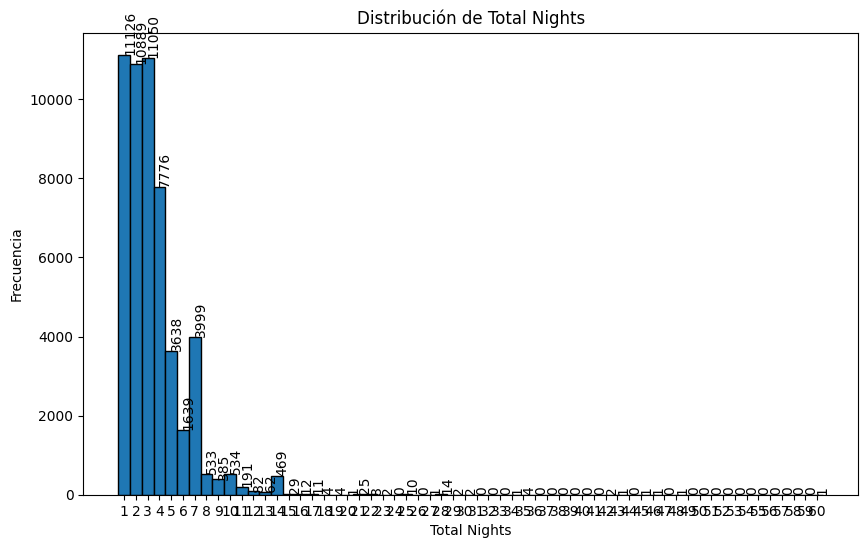

In [19]:
import matplotlib.pyplot as plt

# Crear el histograma de total_nights
plt.figure(figsize=(10, 6))
bars = plt.hist(df_train['total_nights'], bins=range(1, df_train['total_nights'].max() + 2), edgecolor='black', align='left')
plt.title('Distribución de Total Nights')
plt.xlabel('Total Nights')
plt.ylabel('Frecuencia')

# Añadir etiquetas en la parte superior de cada barra
for i, count in enumerate(bars[0]):
    plt.text(bars[1][i] + 0.5, count, str(int(count)), ha='center', va='bottom', rotation=90)

plt.xticks(range(1, df_train['total_nights'].max() + 1))
plt.show()

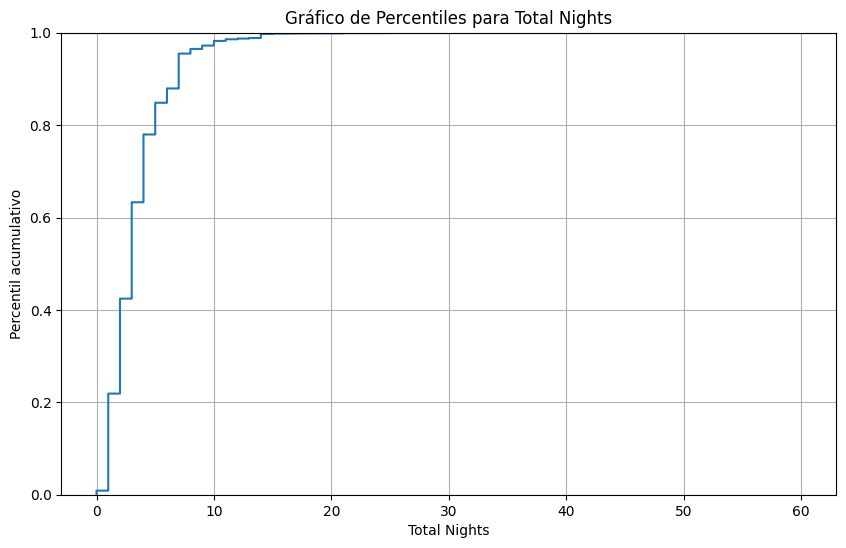

In [20]:
import seaborn as sns
import matplotlib.pyplot as plt

# Crear un gráfico de percentiles para total_nights
plt.figure(figsize=(10, 6))
sns.ecdfplot(df_train['total_nights'], complementary=False)
plt.title('Gráfico de Percentiles para Total Nights')
plt.xlabel('Total Nights')
plt.ylabel('Percentil acumulativo')
plt.grid()
plt.show()

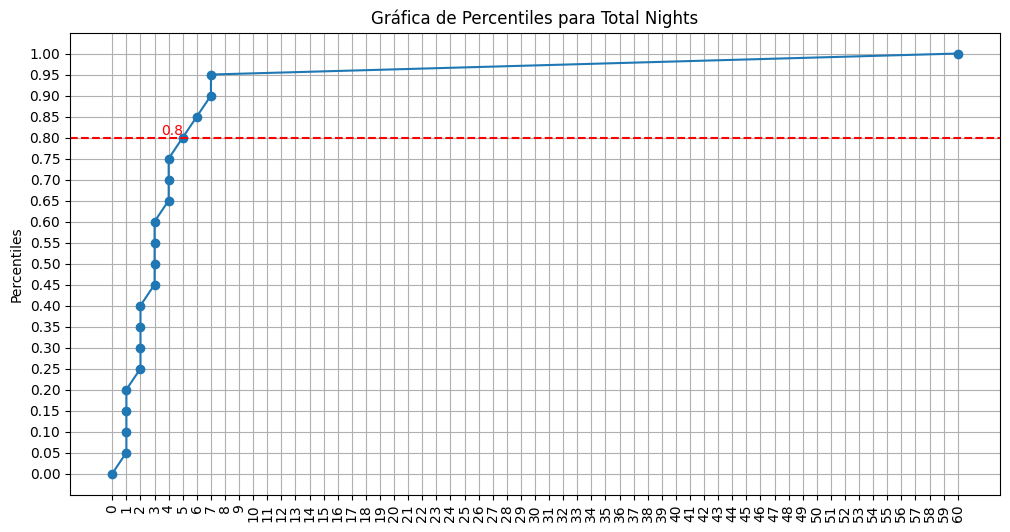

In [21]:
import numpy as np
import matplotlib.pyplot as plt

# Calcular percentiles del 0 al 1 con paso de 0.05
percentiles = np.arange(0, 1.05, 0.05)
nights_percentiles = np.percentile(df_train['total_nights'], percentiles * 100)

# Crear la gráfica
plt.figure(figsize=(12, 6))
plt.plot(nights_percentiles, percentiles, marker='o')

# Agregar una línea horizontal en el percentil 0.8
plt.axhline(y=0.8, color='r', linestyle='--')
plt.text(nights_percentiles[16], 0.8, '0.8', color='red', va='bottom', ha='right')

# Configurar etiquetas y rotación del eje X
plt.xticks(ticks=np.arange(min(nights_percentiles), max(nights_percentiles) + 1, 1), rotation=90)
plt.yticks(np.arange(0, 1.05, 0.05))

# Título y etiquetas de ejes
plt.title('Gráfica de Percentiles para Total Nights')
plt.ylabel('Percentiles')
plt.xlabel('')  # Sin título en el eje X
plt.grid()

plt.show()

C:\Users\Javier_Castillo\AppData\Local\Temp\ipykernel_5324\179733275.py:13: UserWarning: FixedFormatter should only be used together with FixedLocator
  ax.set_xticklabels(ax.get_xticks(), rotation=90)


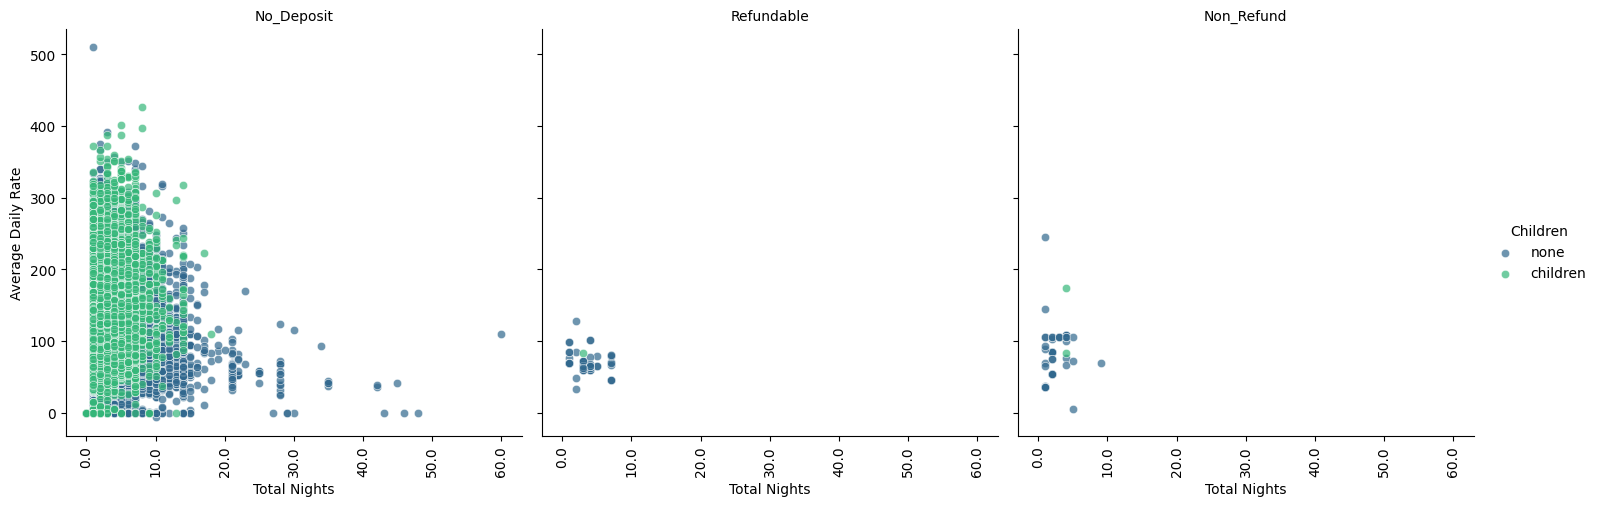

In [22]:
import seaborn as sns
import matplotlib.pyplot as plt

# Crear una figura con subplots por cada tipo de deposit_type
g = sns.FacetGrid(df_train, col='deposit_type', hue='children', palette='viridis', height=5)
g.map(sns.scatterplot, 'total_nights', 'average_daily_rate', alpha=0.7)

# Añadir leyenda y etiquetas
g.add_legend(title="Children")
g.set_axis_labels("Total Nights", "Average Daily Rate")
g.set_titles("{col_name}")
for ax in g.axes.flat:
    ax.set_xticklabels(ax.get_xticks(), rotation=90)

plt.show()

In [25]:
# Crear la columna stays_in_weekend (1 si tiene noches de fin de semana, 0 en caso contrario)
df_train['stays_in_weekend'] = (df_train['stays_in_weekend_nights'] > 0).astype(int)

# Crear la columna stay_days para clasificar las reservas según los días de permanencia
df_train['stay_days'] = 'both'  # Valor por defecto

# Asignar valores condicionales
df_train.loc[(df_train['stays_in_weekend_nights'] > 0) & (df_train['stays_in_week_nights'] == 0), 'stay_days'] = 'weekend'
df_train.loc[(df_train['stays_in_weekend_nights'] == 0) & (df_train['stays_in_week_nights'] > 0), 'stay_days'] = 'weekdays'

# Visualizar las primeras filas para verificar
df_train[['stays_in_weekend_nights', 'stays_in_week_nights', 'stays_in_weekend', 'stay_days']].head()

,stays_in_weekend_nights,stays_in_week_nights,stays_in_weekend,stay_days
0,0,0,0,both
1,0,0,0,both
2,0,1,0,weekdays
3,0,1,0,weekdays
4,0,2,0,weekdays


In [28]:
# exportar 10 filas de df_train a un archivo CSV y sobreescribir si ya existe
df_train.head(10).to_csv('df_train_10.csv', index=False)